# Overfitting and Underfitting Workshop

## Understanding the Bias-Variance Tradeoff

This workshop explores the fundamental challenge in machine learning: finding the sweet spot between models that are too simple (underfitting) and models that are too complex (overfitting).

### Learning Objectives
By the end of this workshop, you will:
- Understand the concepts of overfitting, underfitting, and the bias-variance tradeoff
- Recognize visual indicators of overfitting in residual plots and prediction plots
- Evaluate models using train/test splits and performance metrics
- Understand how model complexity, data quality, and noise affect generalization
- Apply regularization and model selection strategies

---

## Theory: The Bias-Variance Tradeoff

### Key Definitions

**Bias:** The error from incorrect assumptions in the learning algorithm. High bias means the model is too simple to capture the underlying pattern.

**Variance:** The sensitivity of the model to small fluctuations in the training data. High variance means the model fits the noise in the training data.

**Overfitting:** When a model learns the training data too well, including its noise. Result: high training accuracy but poor test accuracy.

**Underfitting:** When a model is too simple to capture the underlying pattern. Result: poor performance on both training and test data.

### The Tradeoff
- Simple models → High bias, Low variance → Underfitting
- Complex models → Low bias, High variance → Overfitting
- Optimal model → Balanced bias and variance → Best generalization

### Visual Indicators
- **Residual plots:** Random scatter around zero = good fit; patterns = model issues
- **Actual vs Predicted plots:** Points close to diagonal = good fit; scattered = poor fit
- **Train vs Test performance:** Large gap = overfitting; both poor = underfitting

---

## Section 1: Simple Models vs Complex Models

### Setup
We'll create a synthetic regression dataset with:
- 500 samples
- 20 features (only 5 are truly informative)
- Noise and redundant features

### Models
1. **Decision Tree (unrestricted):** Complex model, prone to overfitting
2. **Linear Regression:** Simple model, may underfit complex patterns

### Evaluation Strategy
- Compare R² scores on training vs test sets
- Analyze residual plots (should be randomly scattered)
- Examine actual vs predicted plots (should follow diagonal)

DecisionTreeRegressor
  Train R^2: 1.0
  Test R^2:  0.6737529415417661
  Train residuals mean: 0.0 std: 0.0
  Test residuals mean:  5.444695876043738 std: 37.27182862674631
LinearRegression
  Train R^2: 0.956475830747689
  Test R^2:  0.9563492473141539
  Train residuals mean: -2.7203636169100977e-15 std: 14.99172213724381
  Test residuals mean:  3.1272618284881486 std: 13.418472795750576


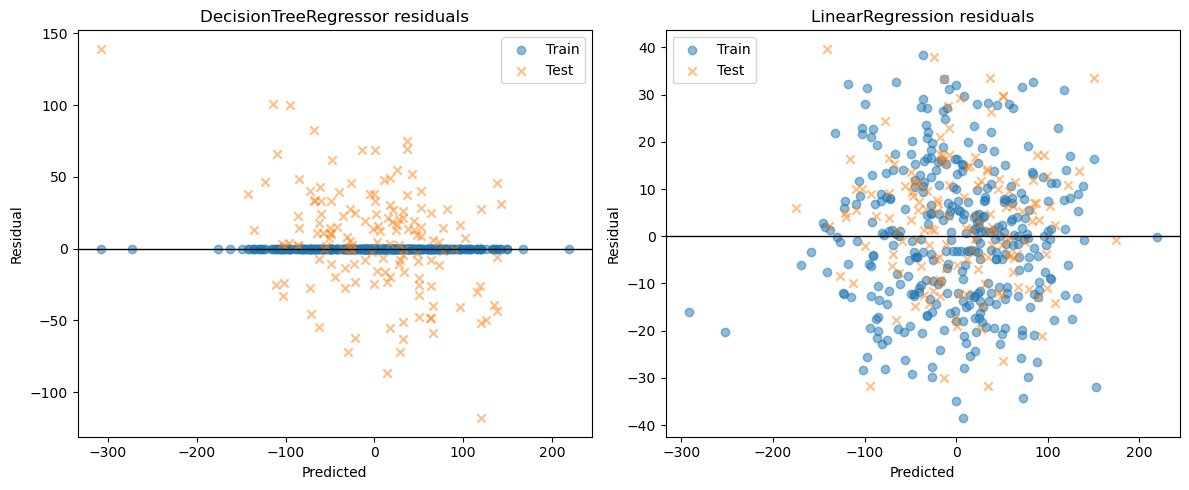

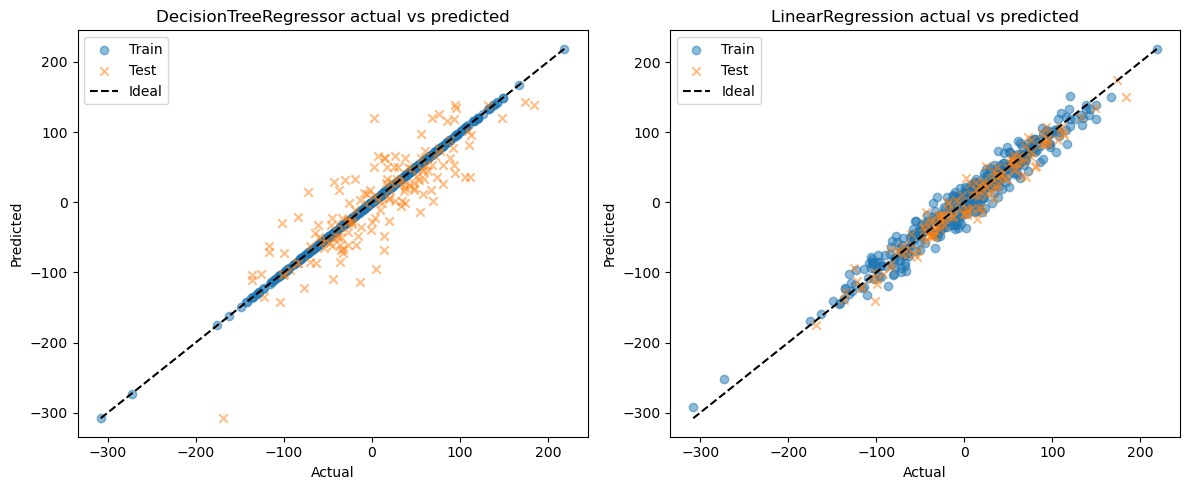

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# create synthetic regression data with redundant features and noise
X, y = make_regression(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_targets=1,
    noise=15.0,
    effective_rank=None,
    tail_strength=0.5,
    random_state=42,
)

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# unrestricted DecisionTreeRegressor (prone to overfitting)
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# simple LinearRegression (likely underfits relative to tree in this setting)
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# evaluate both models
y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)
y_train_lin = linreg.predict(X_train)
y_test_lin = linreg.predict(X_test)

train_resid_tree = y_train - y_train_tree
test_resid_tree = y_test - y_test_tree
train_resid_lin = y_train - y_train_lin
test_resid_lin = y_test - y_test_lin

print("DecisionTreeRegressor")
print("  Train R^2:", r2_score(y_train, y_train_tree))
print("  Test R^2: ", r2_score(y_test, y_test_tree))
print("  Train residuals mean:", np.mean(train_resid_tree), "std:", np.std(train_resid_tree))
print("  Test residuals mean: ", np.mean(test_resid_tree), "std:", np.std(test_resid_tree))

print("LinearRegression")
print("  Train R^2:", r2_score(y_train, y_train_lin))
print("  Test R^2: ", r2_score(y_test, y_test_lin))
print("  Train residuals mean:", np.mean(train_resid_lin), "std:", np.std(train_resid_lin))
print("  Test residuals mean: ", np.mean(test_resid_lin), "std:", np.std(test_resid_lin))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train_tree, train_resid_tree, alpha=0.5, label="Train")
plt.scatter(y_test_tree, test_resid_tree, alpha=0.5, label="Test", marker="x")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("DecisionTreeRegressor residuals")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_train_lin, train_resid_lin, alpha=0.5, label="Train")
plt.scatter(y_test_lin, test_resid_lin, alpha=0.5, label="Test", marker="x")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("LinearRegression residuals")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_tree, alpha=0.5, label="Train")
plt.scatter(y_test, y_test_tree, alpha=0.5, label="Test", marker="x")
y_vals = np.concatenate([y_train, y_test])
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], "k--", label="Ideal")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("DecisionTreeRegressor actual vs predicted")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_train, y_train_lin, alpha=0.5, label="Train")
plt.scatter(y_test, y_test_lin, alpha=0.5, label="Test", marker="x")
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], "k--", label="Ideal")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LinearRegression actual vs predicted")
plt.legend()

plt.tight_layout()
plt.show()

---

## Section 2: The Role of Noise and Data Complexity

### Friedman1 Dataset
This is a more complex, non-linear regression dataset:
- More challenging true function
- Higher inherent noise
- Decision trees excel at capturing non-linear patterns, but risk overfitting to noise

### What to Observe
1. **Performance gap:** Notice the R² difference between train and test for the decision tree
2. **Noise sensitivity:** How does the model react to high noise?
3. **Linear model limitation:** Can a simple linear model capture the complexity?

DecisionTreeRegressor
  Train R^2: 1.0
  Test R^2:  -1.3823502307053426
LinearRegression
  Train R^2: 0.08367331363554531
  Test R^2:  -0.1604622143347536


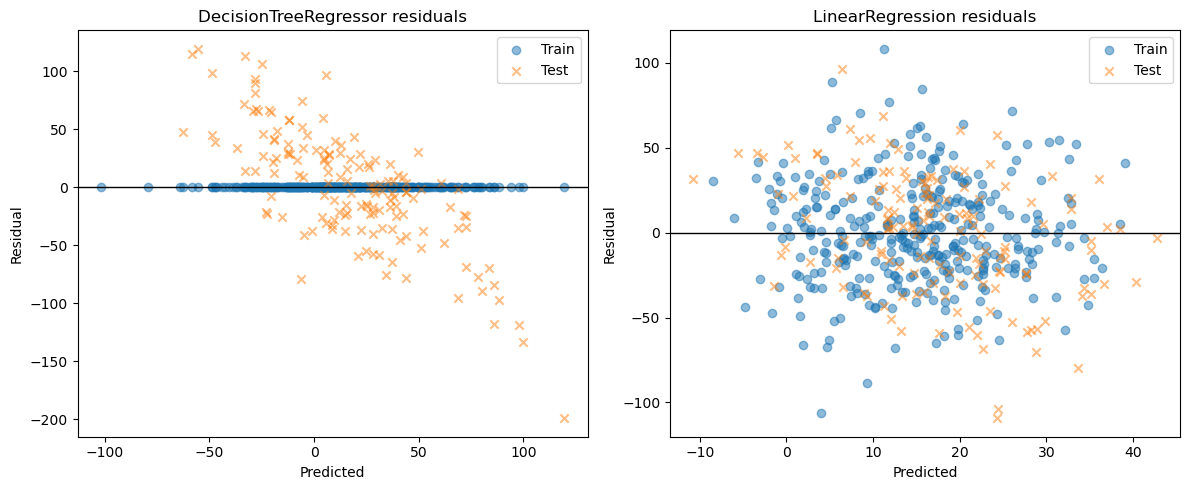

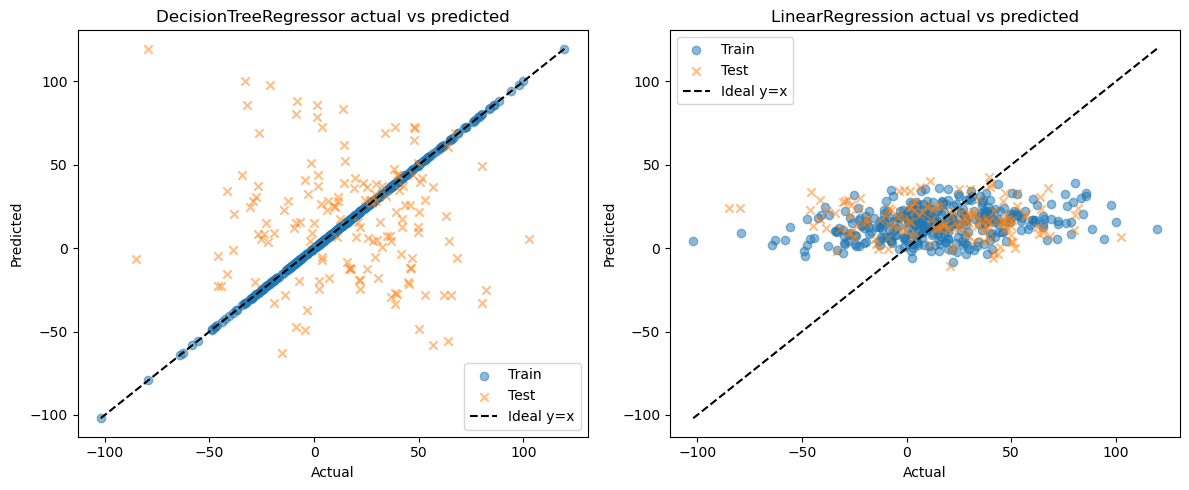

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# create a complex non-linear regression dataset with redundant features and high noise
X, y = make_friedman1(
    n_samples=500,
    n_features=20,
    noise=30.0,
    random_state=42,
)

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# unpruned DecisionTreeRegressor (likely to overfit noisy training data)
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# simple LinearRegression for comparison
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# evaluate both models
y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)
y_train_lin = linreg.predict(X_train)
y_test_lin = linreg.predict(X_test)

train_resid_tree = y_train - y_train_tree
test_resid_tree = y_test - y_test_tree
train_resid_lin = y_train - y_train_lin
test_resid_lin = y_test - y_test_lin

print("DecisionTreeRegressor")
print("  Train R^2:", r2_score(y_train, y_train_tree))
print("  Test R^2: ", r2_score(y_test, y_test_tree))

print("LinearRegression")
print("  Train R^2:", r2_score(y_train, y_train_lin))
print("  Test R^2: ", r2_score(y_test, y_test_lin))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train_tree, train_resid_tree, alpha=0.5, label="Train")
plt.scatter(y_test_tree, test_resid_tree, alpha=0.5, label="Test", marker="x")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("DecisionTreeRegressor residuals")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_train_lin, train_resid_lin, alpha=0.5, label="Train")
plt.scatter(y_test_lin, test_resid_lin, alpha=0.5, label="Test", marker="x")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("LinearRegression residuals")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_tree, alpha=0.5, label="Train")
plt.scatter(y_test, y_test_tree, alpha=0.5, label="Test", marker="x")
y_vals = np.concatenate([y_train, y_test])
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], "k--", label="Ideal y=x")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("DecisionTreeRegressor actual vs predicted")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_train, y_train_lin, alpha=0.5, label="Train")
plt.scatter(y_test, y_test_lin, alpha=0.5, label="Test", marker="x")
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], "k--", label="Ideal y=x")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LinearRegression actual vs predicted")
plt.legend()

plt.tight_layout()
plt.show()

---

## Section 3: Visualizing Overfitting on Simple Data

### The Sine Wave Example
A classic example with:
- True function: sin(x)
- Added Gaussian noise
- Simple 1D data for easy visualization

### Models Compared
1. **Simple Linear Model:** Polynomial degree 1 (straight line) - underfits
2. **Decision Tree (unrestricted):** Complex tree that memorizes data - overfits

### What to See
- The true sine curve (black line)
- Training points (blue dots) vs test points (orange x's)
- How the overfit tree wiggles to pass through training points
- How the simple linear model misses the underlying curve structure

This visual example makes the bias-variance tradeoff crystal clear!

Simple linear model
  Train R^2: 0.5414074388503662
  Test  R^2: 0.5536086627017981
Overfit DecisionTreeRegressor
  Train R^2: 1.0
  Test  R^2: 0.9244652035902252


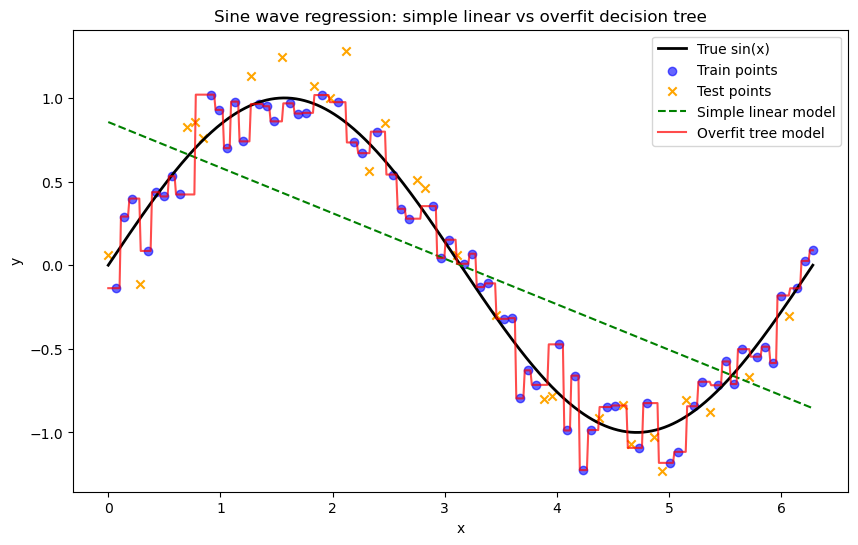

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

rng = np.random.default_rng(42)
n_samples = 90

X = np.linspace(0, 2 * np.pi, n_samples).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + rng.normal(scale=0.2, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

simple_model = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
simple_model.fit(X_train, y_train)

overfit_model = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

y_train_simple = simple_model.predict(X_train)
y_test_simple = simple_model.predict(X_test)
y_train_over = overfit_model.predict(X_train)
y_test_over = overfit_model.predict(X_test)

print("Simple linear model")
print("  Train R^2:", r2_score(y_train, y_train_simple))
print("  Test  R^2:", r2_score(y_test, y_test_simple))

print("Overfit DecisionTreeRegressor")
print("  Train R^2:", r2_score(y_train, y_train_over))
print("  Test  R^2:", r2_score(y_test, y_test_over))

X_plot = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)
y_plot_true = np.sin(X_plot)
y_plot_simple = simple_model.predict(X_plot)
y_plot_over = overfit_model.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.plot(X_plot, y_plot_true, label="True sin(x)", color="black", linewidth=2)
plt.scatter(X_train, y_train, label="Train points", color="blue", alpha=0.6)
plt.scatter(X_test, y_test, label="Test points", color="orange", marker="x")
plt.plot(X_plot, y_plot_simple, label="Simple linear model", color="green", linestyle="--")
plt.plot(X_plot, y_plot_over, label="Overfit tree model", color="red", alpha=0.7)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sine wave regression: simple linear vs overfit decision tree")
plt.show()

---

## Key Takeaways

### How to Detect Overfitting
1. **Large train-test gap:** Train R² >> Test R² indicates overfitting
2. **Residual patterns:** Non-random patterns suggest model issues
3. **Visual fit:** Wiggly predictions on smooth data suggest overfitting
4. **Test performance:** Poor test performance with good training performance

### Strategies to Combat Overfitting
1. **Reduce complexity:** Use simpler models (lower tree depth, fewer features)
2. **Regularization:** Add penalties for model complexity (L1/L2 regularization)
3. **More data:** Overfitting is less likely with larger datasets
4. **Cross-validation:** Use k-fold cross-validation for robust evaluation
5. **Feature selection:** Remove irrelevant or redundant features
6. **Early stopping:** Stop training before overfitting occurs

### The Goal
Find the "sweet spot" where:
- Model is simple enough to not fit noise (low variance)
- Model is complex enough to capture the pattern (low bias)
- This is the **Bias-Variance Tradeoff**

### Practical Workflow
1. Start with a simple model (establishes baseline)
2. Gradually increase complexity
3. Monitor train and test performance
4. Stop when test performance plateaus or decreases
5. Use domain knowledge to guide model selection

---

## Reflection Questions & Exercises

### Reflection Questions
1. In Section 1, what is the R² difference between training and test for the Decision Tree? What does this tell you?
2. Why does the simple Linear Regression perform relatively better on the Friedman1 data?
3. In Section 3 (sine wave), where does the overfit tree fit best and where does it fail?
4. How would you expect performance to change if you had 10x more training data?

### Exercises to Try

**Exercise 1:** Modify the Decision Tree in Section 1
- Try adding `max_depth=5` or `max_depth=3` to the DecisionTreeRegressor
- How does the train/test gap change?
- What happens to the residual plots?

**Exercise 2:** Add Regularization
- In Section 1, try `max_features` parameter on the DecisionTreeRegressor
- Compare results with and without this constraint

**Exercise 3:** Increase Data
- In Section 3, increase `n_samples` from 90 to 300
- Does the overfit model still overfit as severely?
- How do the residual patterns change?

**Exercise 4:** Cross-Validation
- Use `cross_val_score` from scikit-learn on both models
- How does it compare to the simple train/test split?

### Further Reading
- **Concept:** Bias-Variance Tradeoff (Geman et al., 1992)
- **Regularization:** Ridge and Lasso Regression
- **Validation:** K-Fold Cross-Validation, Learning Curves
- **Tools:** Scikit-learn regularization parameters